Time column is increasing: True
Missing values:
0_y     0
13_y    0
14_y    0
17_y    0
37_y    0
dtype: int64


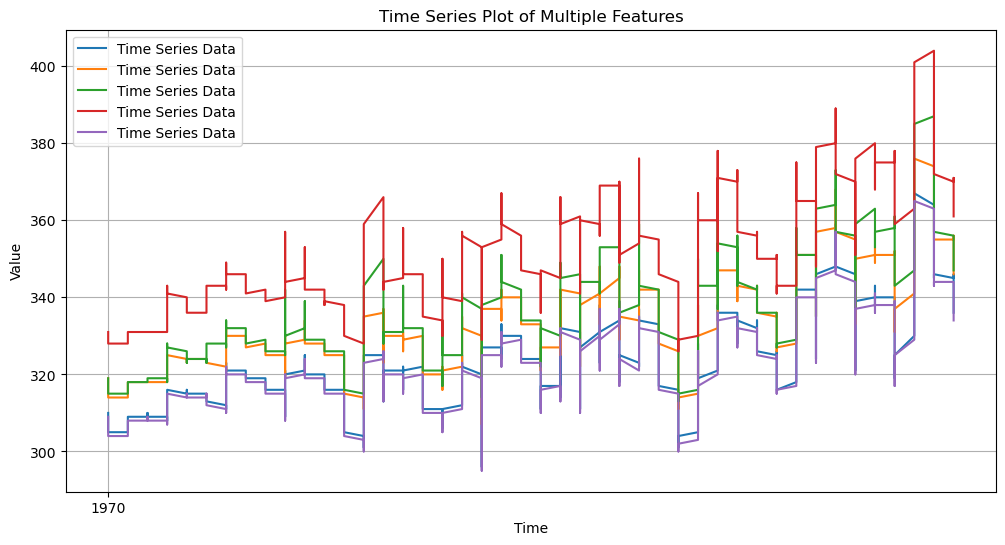

In [41]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.statespace.varmax import VARMAX
from sklearn.metrics import mean_absolute_error, mean_squared_error

# 1. Veri Setini Yükleme
file_path = "data/selected_lip_coordinates_y_only.csv"
df = pd.read_csv(file_path)
df['time'] = pd.to_datetime(df['time'])
df.set_index("time", inplace=True)
freq = pd.infer_freq(df.index)
if freq is not None:
    df = df.asfreq(freq)

# 2. Zaman Serisi Doğrulama
print("Time column is increasing:", df.index.is_monotonic_increasing)
print("Missing values:")
print(df.isnull().sum())

# 3. Zaman Serisi Görselleştirme
plt.figure(figsize=(12, 6))
plt.plot(df, label="Time Series Data")
plt.xlabel("Time")
plt.ylabel("Value")
plt.title("Time Series Plot of Multiple Features")
plt.legend()
plt.grid(True)
plt.show()
plt.close()

In [42]:
# 4. ADF Durağanlık Testi ve Durağan Olmayanlara Fark Alma
def adf_test(series):
    result = adfuller(series.dropna())
    print(f"ADF Statistic: {result[0]}")
    print(f"p-value: {result[1]}")
    print("Critical Values:")
    for key, value in result[4].items():
        print(f"   {key}: {value}")
    if result[1] <= 0.05:
        print("Seri durağandır.")
        return True
    else:
        print("Seri durağan değildir.")
        return False

print("Durağanlık Testi Sonuçları:")
non_stationary_columns = []
for column in df.columns:
    print(f"\n{column} için ADF Testi:")
    is_stationary = adf_test(df[column])
    if not is_stationary:
        non_stationary_columns.append(column)

Durağanlık Testi Sonuçları:

0_y için ADF Testi:
ADF Statistic: -3.7485014333320894
p-value: 0.003480414287093404
Critical Values:
   1%: -3.4363635475753824
   5%: -2.864195245967465
   10%: -2.5681837404258903
Seri durağandır.

13_y için ADF Testi:
ADF Statistic: -3.000433760974851
p-value: 0.03485391230900469
Critical Values:
   1%: -3.436391325753478
   5%: -2.864207498909067
   10%: -2.5681902663042324
Seri durağandır.

14_y için ADF Testi:
ADF Statistic: -3.151844102169366
p-value: 0.022946895286145602
Critical Values:
   1%: -3.436402509014354
   5%: -2.8642124318084456
   10%: -2.568192893555997
Seri durağandır.

17_y için ADF Testi:
ADF Statistic: -3.0837762846470715
p-value: 0.027777346392390708
Critical Values:
   1%: -3.436402509014354
   5%: -2.8642124318084456
   10%: -2.568192893555997
Seri durağandır.

37_y için ADF Testi:
ADF Statistic: -3.7284330287792766
p-value: 0.0037305356545876025
Critical Values:
   1%: -3.4363635475753824
   5%: -2.864195245967465
   10%: -2.56

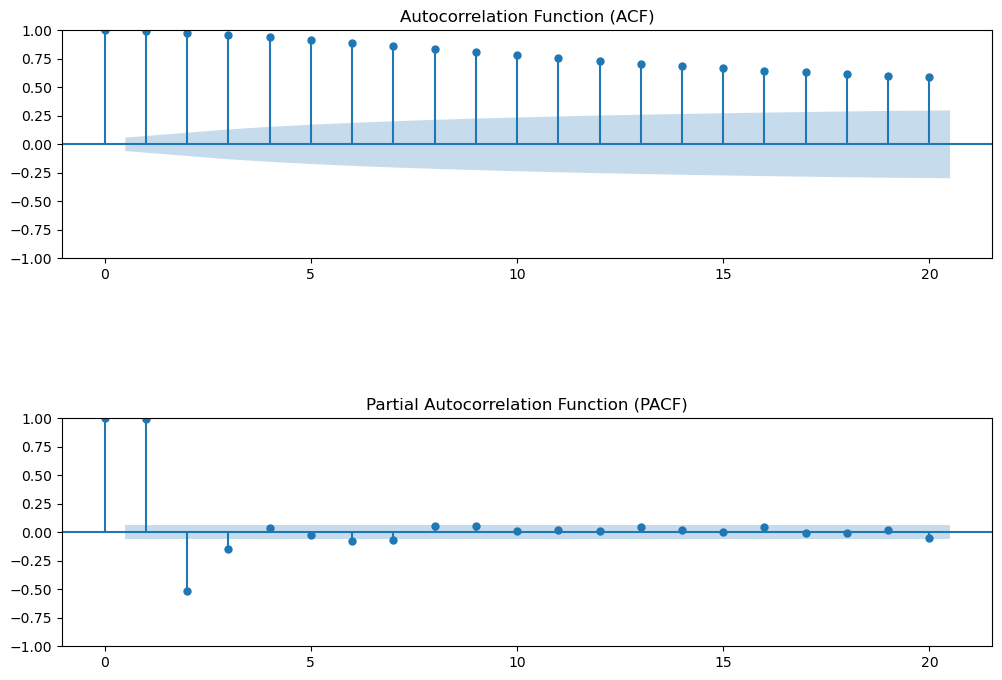

In [43]:
# 5. ACF ve PACF Grafikleri
fig, ax = plt.subplots(2, 1, figsize=(12, 8))
plot_acf(df.dropna().iloc[:, 0], ax=ax[0], lags=20)
ax[0].set_title("Autocorrelation Function (ACF)")
plot_pacf(df.dropna().iloc[:, 0], ax=ax[1], lags=20)
ax[1].set_title("Partial Autocorrelation Function (PACF)")
plt.subplots_adjust(hspace=0.7, wspace=0.4)
plt.show()

In [75]:
# 6. Tüm zaman adımları için tahmin yapma
forecast_steps = len(df) - 1  # Son gözlem için tahmin yapılamaz

predictions = []
real_values = []

for i in range(forecast_steps):  # Son değere kadar döngü
    train_data = df.iloc[:i + 1]  # İlk i+1 gözlemi al
    
    # 📌 Minimum veri kontrolü (order=(2,2) için en az 4 gözlem olmalı)
    if len(train_data) < 4:
        continue
    
    # VARMA Modelini Eğit
    varma_model = VARMAX(train_data.values, order=(2, 2), trend='n').fit(disp=False)
    
    # Son gözlemden bir adım ileri tahmin yap
    next_forecast = varma_model.forecast(steps=1)
    
    predictions.append(next_forecast.iloc[0].values)  # Tahmini sakla
    real_values.append(df.iloc[i + 1].values)  # Gerçek değeri sakla

C:\Users\Gozde\anaconda3\Lib\site-packages\statsmodels\tsa\statespace\varmax.py:160: EstimationWarning: Estimation of VARMA(p,q) models is not generically robust, due especially to identification issues.
  warn('Estimation of VARMA(p,q) models is not generically robust,'


LinAlgError: 1-dimensional array given. Array must be two-dimensional